# Illustration — injection des consignes de setpoint (non stochastiques) dans le time series

**Bâtiment 57826** (Iowa) — tiré des 153 bâtiments filtrés (maison individuelle plain-pied,
chauffage électrique, sans VE/piscine/PV, occupée).

## Problème
Dans la release ResStock 2025, les colonnes `out.schedules.cooling_setpoint..c` et
`out.schedules.heating_setpoint..c` du time series sont **entièrement vides** : les consignes
sont des schedules *non stochastiques*, appliqués dans EnergyPlus mais non ré-exportés.

## Idée
La consigne horaire est **entièrement déterministe** : on la **reconstruit** à partir de
4 caractéristiques statiques (métadonnées) + le masque horaire réel de `options_lookup.tsv`,
puis on l'**injecte** dans le time series et on visualise sa relation avec la température
intérieure réelle (`out.indoor_temperature.conditioned_space..c`).

> On commence par la **climatisation**, puis on montre le rôle **saisonnier** des deux consignes.

## 0. Configuration & imports

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ROOT     = Path.cwd().parents[1] if Path.cwd().name == '06_timeseries' else Path.cwd()
DATA     = ROOT / 'data' / 'processed'
LOOKUP   = ROOT / 'data' / 'external' / 'options_lookup.tsv'

BLDG_ID  = 57826
TS_FILE  = DATA / f'{BLDG_ID}-0_full.parquet'          # time series complet (192 colonnes)
META     = DATA / 'metadata_clean.parquet'
T_COL    = 'out.indoor_temperature.conditioned_space..c'
COOL_COL = 'out.electricity.cooling.energy_consumption..kwh'

plt.rcParams['figure.dpi'] = 110

## 1. Caractéristiques de consigne du bâtiment (statique)

Chaque consigne est décrite par 4 attributs : la **base**, la présence d'un **offset**,
sa **magnitude** (un écart, en °F) et sa **période** (quelles heures, quel sens).

In [2]:
meta  = pd.read_parquet(META)
carac = meta.loc[meta['bldg_id'] == BLDG_ID].iloc[0]

attrs = ['in.state', 'in.hvac_cooling_type', 'in.hvac_heating_type_and_fuel',
         'in.cooling_setpoint', 'in.cooling_setpoint_has_offset',
         'in.cooling_setpoint_offset_magnitude', 'in.cooling_setpoint_offset_period',
         'in.heating_setpoint', 'in.heating_setpoint_has_offset',
         'in.heating_setpoint_offset_magnitude', 'in.heating_setpoint_offset_period']
pd.DataFrame({'valeur': carac[attrs]})

,valeur
in.state,IA
in.hvac_cooling_type,Room AC
in.hvac_heating_type_and_fuel,Electricity Electric Boiler
in.cooling_setpoint,76F
in.cooling_setpoint_has_offset,Yes
in.cooling_setpoint_offset_magnitude,9F
in.cooling_setpoint_offset_period,Day Setup and Night Setback
in.heating_setpoint,68F
in.heating_setpoint_has_offset,Yes
in.heating_setpoint_offset_magnitude,6F


## 2. Reconstruction des consignes horaires

**Conversions °F → °C** — attention à la nature de la grandeur :
- une **consigne** est une température *absolue* → `(F − 32) × 5/9`
- une **magnitude d'offset** est un *écart* → `F × 5/9` (surtout **pas** le −32)

**Masque horaire** (`options_lookup.tsv`) — vecteur de 24 valeurs **signées** :
`+1` = *setup* (consigne relevée), `−1` = *setback* (consigne abaissée), `0` = base.
Le masque diffère entre **semaine** et **week-end**. La consigne finale est simplement :

$$\text{consigne}(h) = \text{base} + \text{masque}(h)\times\text{magnitude}$$

In [3]:
# '76F' -> 24.44  (température absolue)
def f_abs_to_c(txt):
    return round((float(re.search(r'[-\d.]+', str(txt)).group()) - 32) * 5 / 9, 2)

# '9F' -> 5.0  (écart de température : pas de -32)
def f_delta_to_c(txt):
    return round(float(re.search(r'[-\d.]+', str(txt)).group()) * 5 / 9, 2)

# lecture des masques horaires depuis options_lookup.tsv
# (nombre de colonnes variable selon les lignes -> lecture texte brute)
LOOKUP_LINES = LOOKUP.read_text(encoding='utf-8').splitlines()

# renvoie (masque_semaine[24], masque_weekend[24]) pour une période donnée
def get_masks(characteristic, period):
    if pd.isna(period) or str(period).strip().lower() == 'none':
        return np.zeros(24), np.zeros(24)
    prefix = f'{characteristic}\t{period}\t'
    line = next((l for l in LOOKUP_LINES if l.startswith(prefix)), None)
    if line is None:
        raise ValueError(f'{characteristic} / {period} introuvable dans options_lookup')
    wk = re.search(r'weekday_setpoint_schedule=([-\d,\s]+)', line).group(1)
    we = re.search(r'weekend_setpoint_schedule=([-\d,\s]+)', line).group(1)
    to_arr = lambda s: np.array([int(x) for x in s.split(',')][:24], dtype=float)
    return to_arr(wk), to_arr(we)

# série horaire de consigne injectée sur l'index temporel du time series
def reconstruire(ts_index, base_c, mag_c, wk_mask, we_mask):
    h  = ts_index.hour.values
    we = ts_index.dayofweek.values >= 5           # samedi/dimanche
    m  = np.where(we, we_mask[h], wk_mask[h])
    return base_c + m * mag_c

In [4]:
# Consigne CLIM
cool_base = f_abs_to_c(carac['in.cooling_setpoint'])
cool_mag  = f_delta_to_c(carac['in.cooling_setpoint_offset_magnitude'])
cool_per  = carac['in.cooling_setpoint_offset_period']
cool_wk, cool_we = get_masks('Cooling Setpoint Offset Period', cool_per)

# Consigne CHAUFFAGE
heat_base = f_abs_to_c(carac['in.heating_setpoint'])
heat_mag  = f_delta_to_c(carac['in.heating_setpoint_offset_magnitude'])
heat_per  = carac['in.heating_setpoint_offset_period']
heat_wk, heat_we = get_masks('Heating Setpoint Offset Period', heat_per)

print(f'CLIM      base={cool_base}C  mag={cool_mag}C  periode={cool_per}')
print('  masque semaine :', cool_wk.astype(int))
print('  profil semaine :', np.round(cool_base + cool_wk * cool_mag, 1))
print(f'CHAUFFAGE base={heat_base}C  mag={heat_mag}C  periode={heat_per}')
print('  masque semaine :', heat_wk.astype(int))
print('  profil semaine :', np.round(heat_base + heat_wk * heat_mag, 1))

CLIM      base=24.44C  mag=5.0C  periode=Day Setup and Night Setback
  masque semaine : [-1 -1 -1 -1 -1 -1 -1  0  0  1  1  1  1  1  1  1  1  0  0  0  0  0 -1 -1]
  profil semaine : [19.4 19.4 19.4 19.4 19.4 19.4 19.4 24.4 24.4 29.4 29.4 29.4 29.4 29.4
 29.4 29.4 29.4 24.4 24.4 24.4 24.4 24.4 19.4 19.4]
CHAUFFAGE base=20.0C  mag=3.33C  periode=Night +3h
  masque semaine : [ 0 -1 -1 -1 -1 -1 -1 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
  profil semaine : [20.  16.7 16.7 16.7 16.7 16.7 16.7 16.7 16.7 16.7 20.  20.  20.  20.
 20.  20.  20.  20.  20.  20.  20.  20.  20.  20. ]


## 3. Injection dans le time series

In [5]:
ts = pd.read_parquet(TS_FILE).set_index('timestamp').sort_index()

ts['setpoint_cooling..c'] = reconstruire(ts.index, cool_base, cool_mag, cool_wk, cool_we)
ts['setpoint_heating..c'] = reconstruire(ts.index, heat_base, heat_mag, heat_wk, heat_we)

ts[[T_COL, 'setpoint_cooling..c', 'setpoint_heating..c', COOL_COL]].head()

,out.indoor_temperature.conditioned_space..c,setpoint_cooling..c,setpoint_heating..c,out.electricity.cooling.energy_consumption..kwh
timestamp,,,,
2018-01-01 00:15:00,19.721111,19.44,20.00,0.0
2018-01-01 00:30:00,19.722778,19.44,20.00,0.0
2018-01-01 00:45:00,19.722221,19.44,20.00,0.0
2018-01-01 01:00:00,19.722221,19.44,16.67,0.0
2018-01-01 01:15:00,19.722778,19.44,16.67,0.0


## 4. Visualisation 1 — une semaine d'été : consigne clim injectée vs température intérieure

La consigne reconstruite (créneaux) et la température intérieure réelle doivent « se suivre »
quand la clim est active.

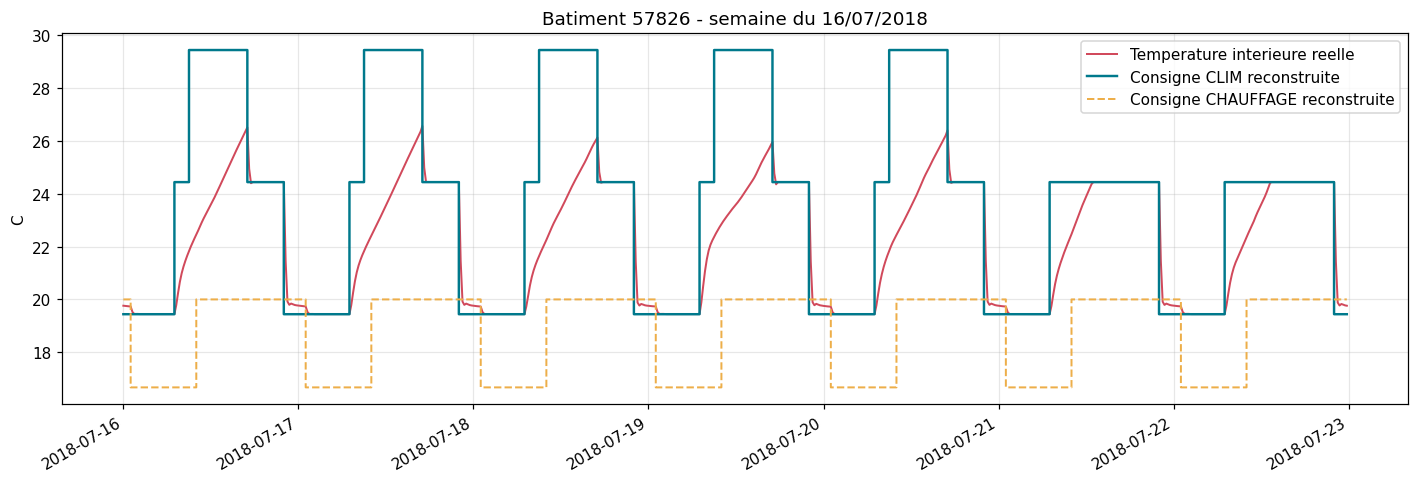

In [6]:
sem = ts.loc['2018-07-16':'2018-07-22']

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(sem.index, sem[T_COL], color='#d1495b', lw=1.3, label='Temperature interieure reelle')
ax.step(sem.index, sem['setpoint_cooling..c'], where='post', color='#00798c', lw=1.6,
        label='Consigne CLIM reconstruite')
ax.step(sem.index, sem['setpoint_heating..c'], where='post', color='#edae49', lw=1.3, ls='--',
        label='Consigne CHAUFFAGE reconstruite')
ax.set_title(f'Batiment {BLDG_ID} - semaine du 16/07/2018')
ax.set_ylabel('C'); ax.legend(loc='upper right'); ax.grid(alpha=.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

**Ce qu'on peut déduire de cette semaine :**

- **La consigne clim est une borne, pas une cible.** La température intérieure est plaquée sur le plancher nocturne (19.4 °C) tant que la clim tient, puis s'en détache et **dérive librement** le jour quand la consigne monte à 29.4 °C (clim à l'arrêt). La Tint n'égale la consigne que sous contrôle actif.
- **La réponse est asymétrique → inertie thermique.** La descente est quasi verticale (la clim refroidit vite), la remontée est **lente et progressive** (dérive gouvernée par l'inertie du bâtiment et la météo). Cette asymétrie révèle la constante de temps du logement.
- **L'effet semaine / week-end se lit à l'œil.** Les 21–22/07, la consigne reste à 24.4 °C en journée (pas de *setup* diurne) au lieu de 29.4 °C en semaine : la distinction du masque `options_lookup` est bien présente dans les données. *(Et le chauffage, en pointillé, n'est jamais atteint — une seule consigne « mord » à la fois.)*

## 5. Visualisation 2 — rôle **saisonnier** des deux consignes (bande morte)

Les consignes ResStock sont **constantes sur l'année** (seule variation : jour/nuit).
Mais un thermostat à double consigne fait **flotter** la température intérieure entre la
consigne chaud (plancher) et la consigne froid (plafond). **Laquelle « mord » est saisonnier** :
- hiver → le chauffage tient le plancher,
- été → la clim tient le plafond.

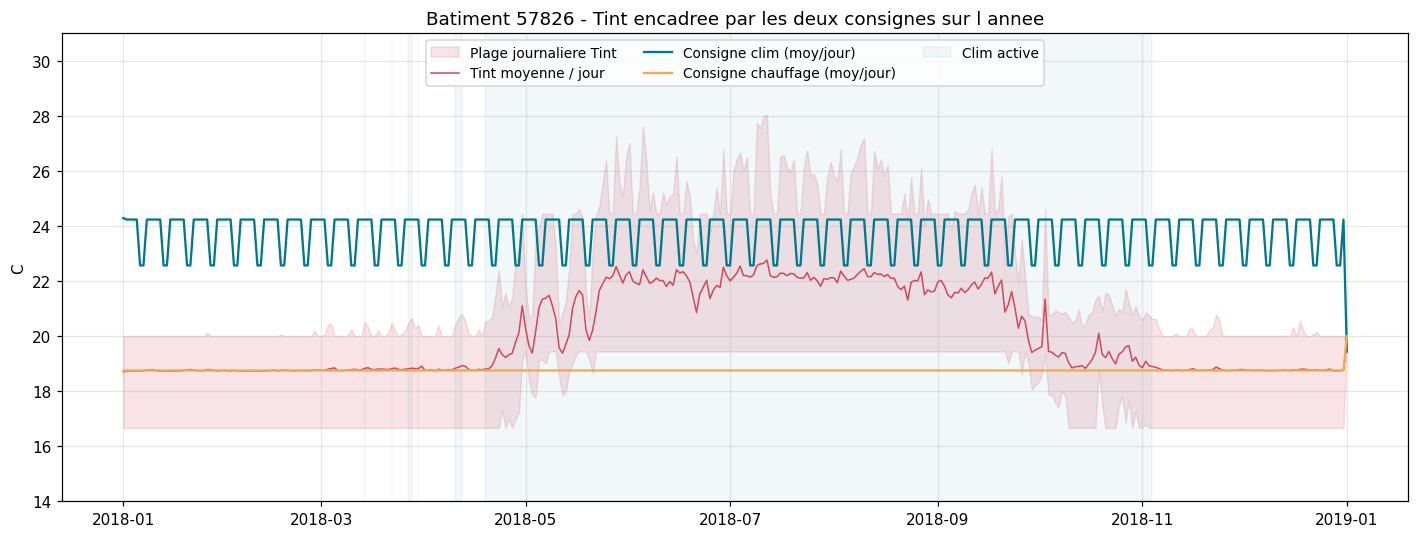

In [7]:
jour = pd.DataFrame({
    'Tint_min': ts[T_COL].resample('D').min(),
    'Tint_moy': ts[T_COL].resample('D').mean(),
    'Tint_max': ts[T_COL].resample('D').max(),
    'cool_sp':  ts['setpoint_cooling..c'].resample('D').mean(),
    'heat_sp':  ts['setpoint_heating..c'].resample('D').mean(),
    'cool_kwh': ts[COOL_COL].resample('D').sum(),
})

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(jour.index, jour['Tint_min'], jour['Tint_max'], color='#d1495b', alpha=.15,
                label='Plage journaliere Tint')
ax.plot(jour.index, jour['Tint_moy'], color='#d1495b', lw=1, label='Tint moyenne / jour')
ax.plot(jour.index, jour['cool_sp'], color='#00798c', lw=1.5, label='Consigne clim (moy/jour)')
ax.plot(jour.index, jour['heat_sp'], color='#edae49', lw=1.5, label='Consigne chauffage (moy/jour)')
active = jour['cool_kwh'] > 0
ax.fill_between(jour.index, 14, 31, where=active, color='#00798c', alpha=.05, label='Clim active')
ax.set_ylim(14, 31); ax.set_ylabel('C')
ax.set_title(f'Batiment {BLDG_ID} - Tint encadree par les deux consignes sur l annee')
ax.legend(loc='upper center', ncol=3, fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Scénario d'occupation : la présence explique la consigne

L'offset de consigne n'est pas arbitraire : il encode le **comportement d'occupation**. La preuve
la plus nette est la distinction **semaine / week-end** du masque, qui s'explique par la présence.

- **En semaine**, on part travailler → occupation en journée ≈ 0.17 → *setup* diurne : on laisse
  la maison se réchauffer (consigne 29.4 °C), la clim se coupe.
- **Le week-end**, on reste chez soi → occupation ≈ 0.87 → **pas** de setup : la consigne reste à
  la base (24.4 °C) et la température aussi.

On lit donc la chaîne **occupation → consigne → température**, en profil 24 h moyen (été).

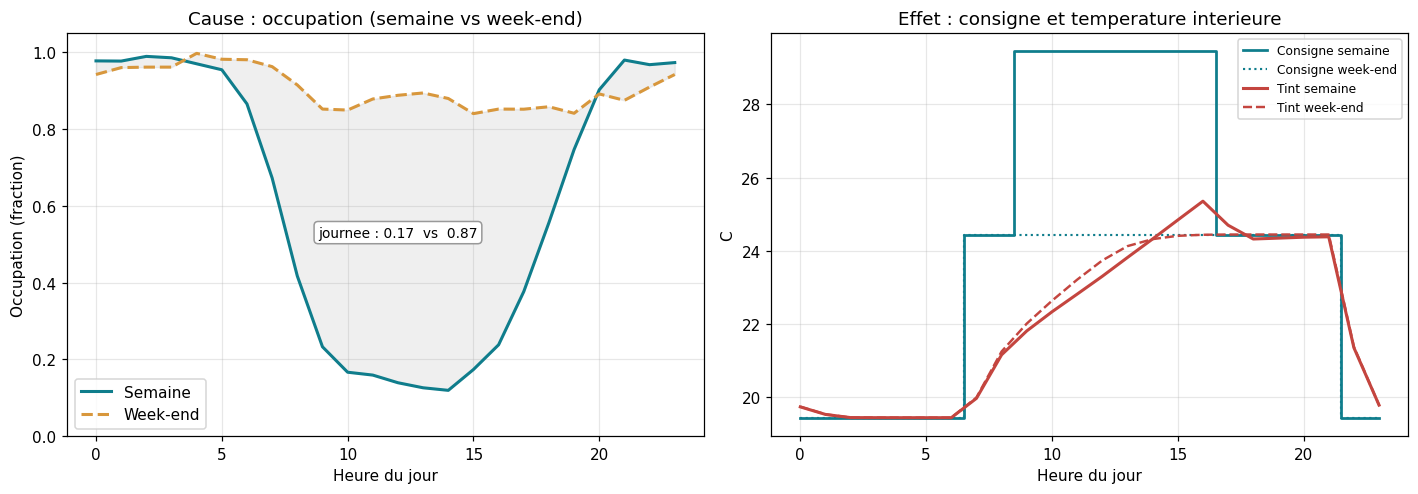

Occupation 9h-16h : semaine 0.17  vs  week-end 0.87
r(occupation, temp. interieure) = -0.42   (present -> plus frais)
r(occupation, conso clim)       = +0.59   (present -> clim active)


In [8]:
s  = ts[ts.index.month.isin([6, 7, 8])]
wk = s[s.index.dayofweek <  5]
we = s[s.index.dayofweek >= 5]
prof = lambda d, c: d[c].groupby(d.index.hour).mean()

occ_wk, occ_we = prof(wk, 'out.schedules.occupants'), prof(we, 'out.schedules.occupants')
sp_wk,  sp_we  = prof(wk, 'setpoint_cooling..c'),     prof(we, 'setpoint_cooling..c')
ti_wk,  ti_we  = prof(wk, T_COL),                     prof(we, T_COL)

r_ot = pearsonr(s['out.schedules.occupants'], s[T_COL])[0]
r_oc = pearsonr(s['out.schedules.occupants'], s[COOL_COL])[0]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# --- CAUSE : occupation ---
ax[0].plot(occ_wk.index, occ_wk.values, color='#0f7d8c', lw=2,           label='Semaine')
ax[0].plot(occ_we.index, occ_we.values, color='#d8973c', lw=2, ls='--',  label='Week-end')
ax[0].fill_between(occ_wk.index, occ_wk.values, occ_we.values, color='#999', alpha=.15)
ax[0].set_xlabel('Heure du jour'); ax[0].set_ylabel('Occupation (fraction)'); ax[0].set_ylim(0, 1.05)
ax[0].set_title('Cause : occupation (semaine vs week-end)')
ax[0].annotate('journee : 0.17  vs  0.87', xy=(12, 0.52), ha='center', fontsize=9,
               bbox=dict(boxstyle='round', fc='white', ec='#999'))
ax[0].legend(loc='lower left'); ax[0].grid(alpha=.3)

# --- EFFET : consigne + temperature ---
ax[1].step(sp_wk.index, sp_wk.values, where='mid', color='#0f7d8c', lw=1.8,          label='Consigne semaine')
ax[1].step(sp_we.index, sp_we.values, where='mid', color='#0f7d8c', lw=1.4, ls=':',  label='Consigne week-end')
ax[1].plot(ti_wk.index, ti_wk.values, color='#c4453f', lw=2,          label='Tint semaine')
ax[1].plot(ti_we.index, ti_we.values, color='#c4453f', lw=1.6, ls='--', label='Tint week-end')
ax[1].set_xlabel('Heure du jour'); ax[1].set_ylabel('C')
ax[1].set_title('Effet : consigne et temperature interieure')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'Occupation 9h-16h : semaine {occ_wk[9:17].mean():.2f}  vs  week-end {occ_we[9:17].mean():.2f}')
print(f'r(occupation, temp. interieure) = {r_ot:+.2f}   (present -> plus frais)')
print(f'r(occupation, conso clim)       = {r_oc:+.2f}   (present -> clim active)')

## 7. Chauffage en hiver : le setback suit le sommeil, pas l'absence

Le chauffage **inverse** la logique de la clim. Ici l'offset est nocturne (« Night +3h ») :

- le **setback** a lieu la **nuit**, quand l'occupation est maximale (≈ 0.97, on dort) → il suit le
  **sommeil**, pas l'absence. Contrairement à la clim, la journée d'absence ne déclenche rien
  (pas de *day setback* pour ce bâtiment : consigne tenue à 20 °C).
- la grosse charge de chauffage est la **relance matinale** (~11 h) : quand la consigne repasse de
  16.7 à 20 °C, la chaudière tire à fond pour réchauffer la maison — mais à cette heure les
  occupants sont **déjà partis**.

Conséquence : le chauffage est **faiblement / négativement** corrélé à la présence, à l'opposé de
la clim.

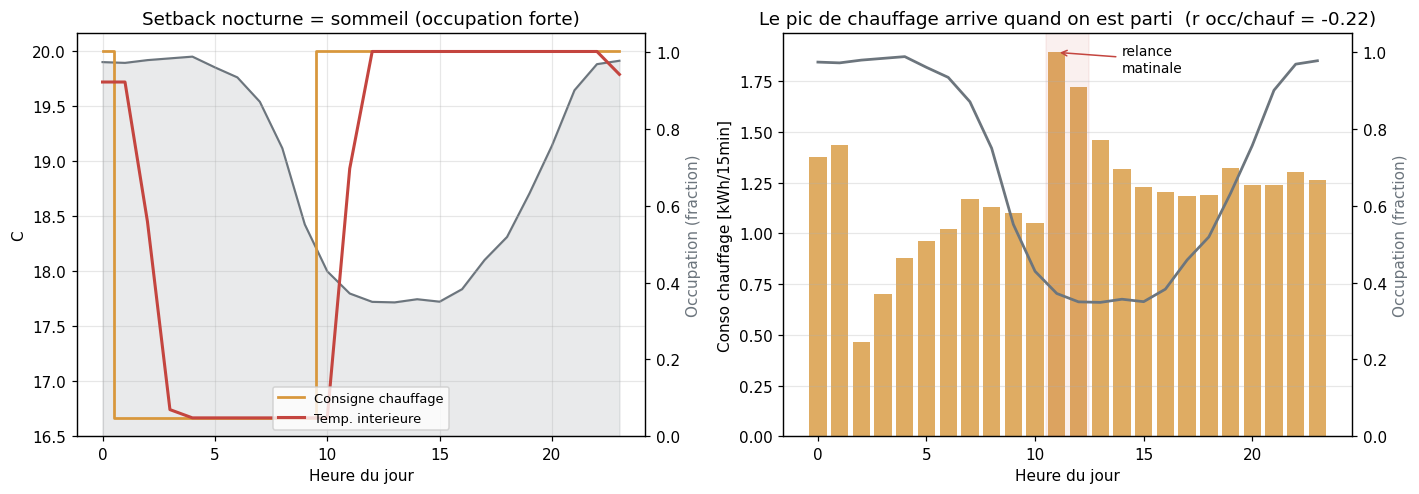

r(occupation, chauffage) hiver = -0.22   (a comparer a +0.59 pour la clim)
conso chauffage : pic 11h = 1.89 kWh  vs  nuit(4h) = 0.88 kWh


In [9]:
HEAT_COL = 'out.electricity.heating.energy_consumption..kwh'
w   = ts[ts.index.month.isin([12, 1, 2])]          # hiver
hh  = w.index.hour
occ = w['out.schedules.occupants'].groupby(hh).mean()
sp  = w['setpoint_heating..c'].groupby(hh).mean()
ti  = w[T_COL].groupby(hh).mean()
heat = w[HEAT_COL].groupby(hh).mean()

r_oh = pearsonr(w['out.schedules.occupants'], w[HEAT_COL])[0]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# --- (1) occupation + consigne chauffage + temperature ---
a0 = ax[0]; b0 = a0.twinx()
b0.fill_between(occ.index, occ.values, color='#6c757d', alpha=.15)
b0.plot(occ.index, occ.values, color='#6c757d', lw=1.4, label='Occupation')
b0.set_ylabel('Occupation (fraction)', color='#6c757d'); b0.set_ylim(0, 1.05)
a0.step(sp.index, sp.values, where='mid', color='#d8973c', lw=1.8, label='Consigne chauffage')
a0.plot(ti.index, ti.values, color='#c4453f', lw=2, label='Temp. interieure')
a0.set_xlabel('Heure du jour'); a0.set_ylabel('C'); a0.set_zorder(1); a0.patch.set_visible(False)
a0.set_title('Setback nocturne = sommeil (occupation forte)')
a0.legend(loc='lower center', fontsize=8.5); a0.grid(alpha=.3)

# --- (2) conso chauffage + occupation : le pic de relance quand on est parti ---
a1 = ax[1]; b1 = a1.twinx()
a1.bar(heat.index, heat.values, color='#d8973c', alpha=.8)
a1.axvspan(10.5, 12.5, color='#c4453f', alpha=.08)
a1.annotate('relance\nmatinale', xy=(11, heat.max()), xytext=(14, heat.max()*.95),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='#c4453f'))
b1.plot(occ.index, occ.values, color='#6c757d', lw=1.8, label='Occupation')
b1.set_ylabel('Occupation (fraction)', color='#6c757d'); b1.set_ylim(0, 1.05)
a1.set_xlabel('Heure du jour'); a1.set_ylabel('Conso chauffage [kWh/15min]')
a1.set_title(f'Le pic de chauffage arrive quand on est parti  (r occ/chauf = {r_oh:+.2f})')
a1.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

print(f'r(occupation, chauffage) hiver = {r_oh:+.2f}   (a comparer a +0.59 pour la clim)')
print(f'conso chauffage : pic 11h = {heat.max():.2f} kWh  vs  nuit(4h) = {heat[4]:.2f} kWh')

## 8. Saisonnalité, deux autres regards

La Viz 2 montrait la bande morte au fil des jours. Ici, deux angles complémentaires :

- **Signature énergétique** (à gauche) : énergie journalière de chauffage et de clim en fonction de
  la température extérieure. On voit le **point d'équilibre** — une plage de températures douces où
  ni l'un ni l'autre ne tourne — encadré par la montée du chauffage vers le froid et de la clim
  vers le chaud.
- **Régime par mois** (à droite) : part du temps où **le chauffage mord**, où **la clim mord**, ou
  où la maison **flotte** (aucune consigne active). La bascule hiver → été est nette, et les
  **mi-saisons flottent** massivement (mai ≈ 55 %, sept–oct ≈ 49 %) : le climat reste dans la bande
  morte, les consignes ne servent presque pas.

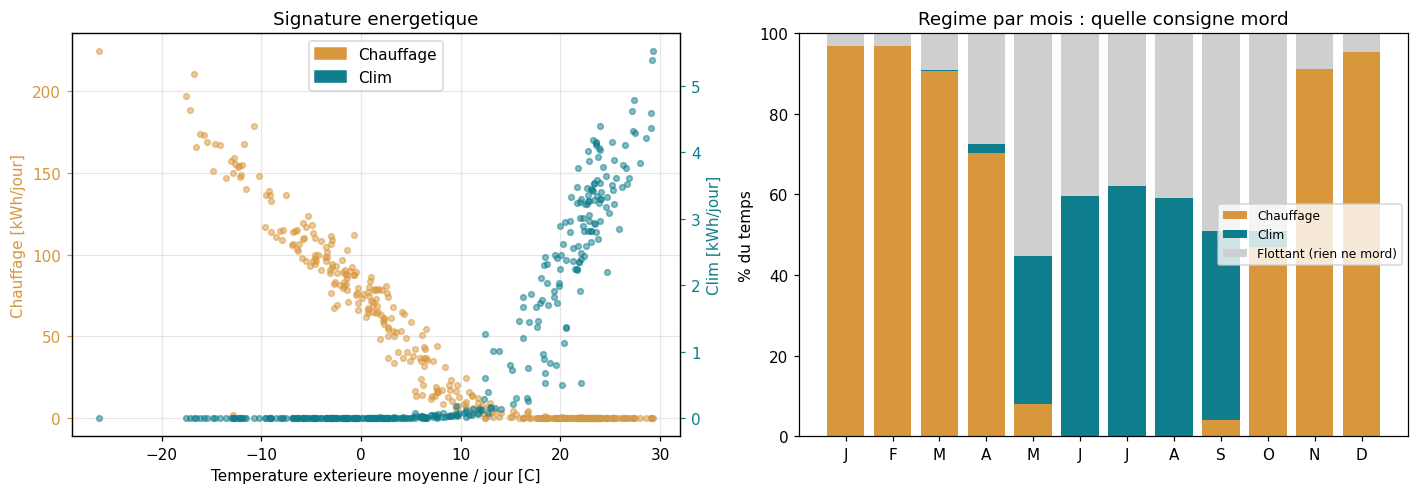

Part du temps flottant (aucune consigne active) :
  mois  1 : 3 %
  mois  5 : 55 %
  mois  7 : 38 %
  mois 10 : 49 %


In [10]:
import matplotlib.patches as mpatches

# --- signature energetique (journalier) ---
d = pd.DataFrame({
    'T': ts['out.outdoor_air_drybulb_temp..c'].resample('D').mean(),
    'H': ts[HEAT_COL].resample('D').sum(),
    'C': ts[COOL_COL].resample('D').sum()})

# --- regime par mois ---
reg = pd.DataFrame({'chauffage': ts[HEAT_COL] > 1e-6, 'clim': ts[COOL_COL] > 1e-6}, index=ts.index)
reg['flottant'] = ~(reg['chauffage'] | reg['clim'])
gm = reg.groupby(reg.index.month).mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# (1) signature : axes jumeaux (chauffage a gauche, clim a droite)
a, b = ax[0], ax[0].twinx()
a.scatter(d['T'], d['H'], s=14, color='#d8973c', alpha=.5)
b.scatter(d['T'], d['C'], s=14, color='#0f7d8c', alpha=.5)
a.set_xlabel('Temperature exterieure moyenne / jour [C]')
a.set_ylabel('Chauffage [kWh/jour]', color='#d8973c')
b.set_ylabel('Clim [kWh/jour]',       color='#0f7d8c')
a.tick_params(axis='y', colors='#d8973c'); b.tick_params(axis='y', colors='#0f7d8c')
a.set_title('Signature energetique'); a.grid(alpha=.3)
a.legend(handles=[mpatches.Patch(color='#d8973c', label='Chauffage'),
                  mpatches.Patch(color='#0f7d8c', label='Clim')], loc='upper center')

# (2) regime par mois (barres empilees)
mois = ['J','F','M','A','M','J','J','A','S','O','N','D']; x = range(1, 13)
a2 = ax[1]
a2.bar(x, gm['chauffage'], color='#d8973c', label='Chauffage')
a2.bar(x, gm['clim'], bottom=gm['chauffage'], color='#0f7d8c', label='Clim')
a2.bar(x, gm['flottant'], bottom=gm['chauffage'] + gm['clim'], color='#cfcfcf',
       label='Flottant (rien ne mord)')
a2.set_xticks(list(x)); a2.set_xticklabels(mois); a2.set_ylabel('% du temps'); a2.set_ylim(0, 100)
a2.set_title('Regime par mois : quelle consigne mord'); a2.legend(fontsize=8, loc='center right')
plt.tight_layout(); plt.show()

print('Part du temps flottant (aucune consigne active) :')
for m in [1, 5, 7, 10]:
    print(f'  mois {m:2d} : {gm["flottant"][m]:.0f} %')